# Modelo predictivo de PM2.5

Este notebook desarrolla un modelo de predicción diaria (a un día vista) de **PM2.5** en las estaciones de calidad del aire de Madrid, siguiendo el **estándar de variables acordado con el equipo** para que todos los modelos del TFM (NO2, PM2.5, etc.) sean comparables entre sí.

## Variables según el estándar del equipo

| Bloque | Variables usadas | Nota |
|---|---|---|
| 🌦️ Meteorología | temperatura, humedad, precipitación, presión, viento (velocidad y racha), dirección de racha | Del día **HOY (T)** — 1 día antes del objetivo (`METEO_LAG_DAYS = 1`), confirmado en reunión de equipo |
| 📅 Calendario | laborable, `mes_sin`, `mes_cos`, día de la semana | Del día objetivo (T+1) |
| 📍 Estación | tipo de estación (tráfico/fondo, one-hot), latitud, longitud, altitud | Fijas por estación |
| ⏳ Histórico PM2.5 (target) | lags 1, 2, 7 días + rolling 3 y 7 días | lag_1 = HOY (T), un día antes del objetivo |
| 🧪 Histórico de otros contaminantes | lags 1, 2, 7 días + rolling 3 y 7 días de NO2, PM10 y O3 (valor propio de cada estación) | Mismo criterio: lag_1 = HOY (T). O3 con baja cobertura (2/8 estaciones), ver nota 2 |
| 🎯 Target | Concentración de PM2.5 en el día objetivo | Modelo entrenado en escala `log1p`, evaluado siempre en µg/m³ |

## Decisiones confirmadas con el equipo

1. ✅ **Desfase de meteorología y contaminantes:** confirmado en reunión de equipo — se usa la información de **HOY (T)** para predecir **MAÑANA (T+1)**. Esto equivale a un desfase de **1 día** entre los datos usados y el día objetivo (`METEO_LAG_DAYS = 1`). Esta decisión reemplaza a la anterior (2 días, basada en una lectura distinta de la notación T−1/T+1) y unifica el criterio: tanto meteo como contaminantes usan ahora el mismo desfase de 1 día, sin necesidad de tratamientos distintos entre ambos.
2. ✅ **O3 con baja cobertura:** se dejan los huecos tal cual (NaN nativo, XGBoost los maneja internamente), sin imputar ni excluir.
3. ✅ **Transformación `log1p` del target:** se mantiene; las métricas finales siempre se reportan en escala original (µg/m³).
4. ✅ **Variables fuera del estándar:** se eliminó `pm25_resto_ciudad_lag_1` (lag espacial), la única variable que realmente no pedía el estándar. Las coordenadas (`LATITUD_G`, `LONGITUD_G`, `ALTITUD`) **no** se consideran "extra": las pide expresamente el estándar.

**Nota histórica:** en una iteración anterior se probó si aplicar un desfase extra (2 días) también a los contaminantes históricos mejoraba el modelo — resultó en un empeoramiento sustancial (MAE 3.25 vs. 2.68 µg/m³). Con la decisión actual del equipo (1 día uniforme para todo), ese problema queda resuelto de raíz: no hace falta tratar meteo y contaminantes de forma distinta.


In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

MAGNITUD_PM25 = 9
MAGNITUD_PM10 = 10
MAGNITUD_NO2 = 8
MAGNITUD_O3 = 14

RANDOM_STATE = 42

# ------------------------------------------------------------
# ESTÁNDAR DEL EQUIPO (confirmado en reunión): se usa la información
# meteorológica y de contaminantes del propio día HOY (T) para predecir
# el día siguiente, MAÑANA (T+1). Esto equivale a un desfase de 1 día
# entre los datos usados y el día objetivo.
# Ejemplo: para predecir el 16 de marzo (T+1), se usa meteo y
# contaminantes del 15 de marzo (T, "hoy").
# ------------------------------------------------------------
METEO_LAG_DAYS = 1


In [2]:
# ============================================================
# LOCALIZACIÓN DEL PROYECTO Y CONEXIÓN A DUCKDB
# (se trabaja directamente sobre los ficheros Parquet de data/enriched,
#  sin depender de que exista una base de datos TFM.duckdb ya construida)
# ============================================================

# Si la detección automática no encuentra la carpeta del proyecto (por ejemplo
# porque el notebook se ejecuta desde un directorio de trabajo distinto al
# esperado), se puede indicar la ruta manualmente aquí. Dejar en None para
# que se busque automáticamente subiendo desde la carpeta actual.
PROJECT_ROOT_OVERRIDE = None  # p. ej.: r"C:\Users\tuusuario\TFM" o "/home/usuario/TFM"

if PROJECT_ROOT_OVERRIDE is not None:
    ROOT = Path(PROJECT_ROOT_OVERRIDE)
    if not (ROOT / "data" / "enriched").exists():
        raise FileNotFoundError(
            f"PROJECT_ROOT_OVERRIDE no contiene data/enriched: {ROOT}"
        )
else:
    _cwd_inicial = Path.cwd()
    ROOT = _cwd_inicial

    while not (ROOT / "data" / "enriched").exists():
        if ROOT.parent == ROOT:
            print("No se ha encontrado 'data/enriched' subiendo desde:", _cwd_inicial)
            print("Carpetas comprobadas hasta llegar a la raíz del sistema.")
            print()
            print("Posibles causas:")
            print("  1) VS Code no tiene abierta la carpeta del repo TFM como workspace")
            print("     (File > Open Folder... y selecciona la carpeta raíz del repo).")
            print("  2) El directorio de trabajo del kernel no es el esperado. Revisa:")
            print("     Settings > busca 'jupyter.notebookFileRoot'.")
            print("  3) La carpeta data/enriched no existe en tu copia local del repo.")
            print()
            print("Alternativa rápida: define PROJECT_ROOT_OVERRIDE arriba con la ruta")
            print("absoluta a la carpeta TFM y vuelve a ejecutar esta celda.")
            raise FileNotFoundError(
                "No se ha encontrado la carpeta data/enriched. "
                "Ver mensaje de diagnóstico impreso arriba."
            )
        ROOT = ROOT.parent

CALIDAD_AIRE_PATH = ROOT / "data" / "enriched" / "fact" / "calidad_aire_final.parquet"
METEO_PATH = ROOT / "data" / "enriched" / "fact" / "meteo_final.parquet"

assert CALIDAD_AIRE_PATH.exists(), f"No se encuentra: {CALIDAD_AIRE_PATH}"
assert METEO_PATH.exists(), f"No se encuentra: {METEO_PATH}"

# Conexión DuckDB "en memoria": no requiere ningún archivo .duckdb previo,
# se usa únicamente como motor SQL para leer los Parquet directamente.
con = duckdb.connect(database=":memory:")

print("Directorio de trabajo detectado:", Path.cwd())
print("Raíz del proyecto:", ROOT)
print("Calidad de aire:", CALIDAD_AIRE_PATH)
print("Meteorología:", METEO_PATH)
print("Conexión a DuckDB (en memoria) realizada correctamente.")


Directorio de trabajo detectado: /home/claude/TFM/src/models/PM25_propio
Raíz del proyecto: /home/claude/TFM
Calidad de aire: /home/claude/TFM/data/enriched/fact/calidad_aire_final.parquet
Meteorología: /home/claude/TFM/data/enriched/fact/meteo_final.parquet
Conexión a DuckDB (en memoria) realizada correctamente.


## 1. Análisis exploratorio propio de PM2.5

Antes de decidir qué variables usar, se analiza la distribución del contaminante, la presencia de valores extremos y su naturaleza (¿ruido o señal real?), y la correlación empírica con meteorología y otros contaminantes. Estas decisiones son las que guían el diseño del dataset de modelado.


In [3]:
# ============================================================
# CARGA DE PM2.5
# ============================================================

pm25 = con.execute(
    """
    SELECT fecha, estacion, uom_value AS pm25, es_laborable_madrid_ciudad
    FROM read_parquet(?)
    WHERE magnitud = ?
    ORDER BY estacion, fecha
    """,
    [str(CALIDAD_AIRE_PATH), MAGNITUD_PM25]
).fetchdf()

pm25["fecha"] = pd.to_datetime(pm25["fecha"])

print("Shape:", pm25.shape)
print("Estaciones:", sorted(pm25['estacion'].unique()))
print("Periodo:", pm25['fecha'].min(), "→", pm25['fecha'].max())
print("Nulos:", pm25['pm25'].isna().sum())
print("Duplicados estacion-fecha:", pm25.duplicated(['estacion','fecha']).sum())


Shape: (14616, 4)
Estaciones: [np.int64(8), np.int64(24), np.int64(38), np.int64(47), np.int64(48), np.int64(50), np.int64(56), np.int64(57)]
Periodo: 2020-01-01 00:00:00 → 2024-12-31 00:00:00
Nulos: 0
Duplicados estacion-fecha: 0


count    14616.000000
mean         9.380798
std          6.181747
min          1.000000
25%          5.166667
50%          8.125000
75%         11.837500
max         84.291667
Name: pm25, dtype: float64

Asimetría (skew): 2.3946947739806053
Curtosis: 12.337754311238093


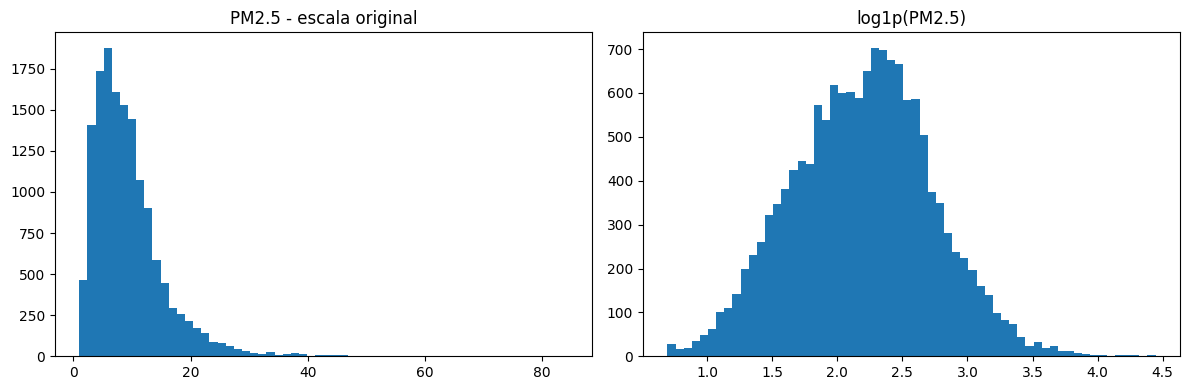

In [4]:
# ============================================================
# DISTRIBUCIÓN DEL TARGET
# ============================================================

print(pm25['pm25'].describe())
print("\nAsimetría (skew):", pm25['pm25'].skew())
print("Curtosis:", pm25['pm25'].kurtosis())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pm25['pm25'], bins=60)
axes[0].set_title("PM2.5 - escala original")
axes[1].hist(np.log1p(pm25['pm25']), bins=60)
axes[1].set_title("log1p(PM2.5)")
plt.tight_layout()
plt.show()


La distribución en escala original está claramente sesgada a la derecha, con una cola larga de valores altos. La transformación `log1p` la aproxima mucho más a una distribución simétrica, lo que favorece el entrenamiento del modelo (los errores en la escala log penalizan de forma proporcional, no absoluta, evitando que unos pocos episodios extremos dominen la función de pérdida).


In [5]:
# ============================================================
# EPISODIO EXTREMO: ¿RUIDO O SEÑAL REAL?
# ============================================================

top_dias = (
    pm25.groupby("fecha")["pm25"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)
print("Días con mayor PM2.5 medio (todas las estaciones):")
print(top_dias)


Días con mayor PM2.5 medio (todas las estaciones):
fecha
2022-03-15    63.223958
2021-01-16    56.369827
2021-01-14    43.544695
2021-01-15    42.069588
2021-01-17    40.144136
Name: pm25, dtype: float64


In [6]:
# Se comprueba si el pico principal afecta a todas las estaciones a la vez
dia_pico = top_dias.index[0]

detalle_pico = pm25[pm25["fecha"] == dia_pico].sort_values("pm25", ascending=False)
print(f"Detalle del {dia_pico.date()} por estación:")
display(detalle_pico)


Detalle del 2022-03-15 por estación:


,fecha,estacion,pm25,es_laborable_madrid_ciudad
2631,2022-03-15,24,84.291667,True
6285,2022-03-15,47,79.166667,True
9939,2022-03-15,50,77.041667,True
13593,2022-03-15,57,69.708333,True
804,2022-03-15,8,66.208333,True
8112,2022-03-15,48,50.708333,True
4458,2022-03-15,38,39.333333,True
11766,2022-03-15,56,39.333333,True


El pico afecta simultáneamente a **todas** las estaciones de la ciudad, lo cual es la firma característica de una **intrusión de polvo sahariano (calima)**, un fenómeno meteorológico regional documentado y frecuente en Madrid en marzo. No se trata de un error de sensor ni de un evento local de tráfico, por lo que **no se elimina** como outlier: es señal real, aunque previsiblemente difícil de predecir con la información disponible en este dataset (no se dispone de datos de concentración de polvo atmosférico ni de trayectorias de masas de aire). Se documenta como limitación conocida del modelo.


## 2. Meteorología: estación más cercana por variable

A cada estación de calidad del aire se le asigna la estación meteorológica AEMET **geográficamente más cercana**, usando las distancias ya calculadas (fórmula Haversine) en `enriched.dim_estaciones_aire` — la misma tabla y el mismo criterio de distancia que usa el resto del proyecto. Como no todas las estaciones meteorológicas reportan todas las variables, el emparejamiento se calcula de forma **independiente para cada variable** (temperatura, viento, presión, etc.), seleccionando en cada caso la estación más cercana que sí disponga de esa variable concreta.


In [7]:
# ============================================================
# METADATA DE ESTACIONES (dim_estaciones_aire, ya con distancias a meteo)
# ============================================================

DIM_ESTACIONES_PATH = ROOT / "data" / "enriched" / "dims" / "dim_estaciones_aire.parquet"

assert DIM_ESTACIONES_PATH.exists(), f"No se encuentra: {DIM_ESTACIONES_PATH}"

estaciones_aire = con.execute(
    """
    SELECT *
    FROM read_parquet(?)
    """,
    [str(DIM_ESTACIONES_PATH)]
).fetchdf()

print("Shape dim_estaciones_aire:", estaciones_aire.shape)
display(estaciones_aire[["ESTACION", "NOMBRE", "LATITUD_G", "LONGITUD_G", "ALTITUD", "TIPO_ESTACION"]].head())


Shape dim_estaciones_aire: (25, 11)


,ESTACION,NOMBRE,LATITUD_G,LONGITUD_G,ALTITUD,TIPO_ESTACION
0,8,ESCUELAS AGUIRRE,40.42167,-3.68222,672,TRAFICO
1,16,ARTURO SORIA,40.44000,-3.63917,698,FONDO
2,17,VILLAVERDE,40.34694,-3.70500,593,FONDO
3,18,FAROLILLO,40.39472,-3.73194,625,FONDO
4,24,CASA DE CAMPO,40.42000,-3.74917,645,FONDO


In [8]:
# ============================================================
# DISTANCIAS A ESTACIONES METEO (desde dim_estaciones_aire.distancias_meteo)
# ============================================================

con.register("estaciones_aire_tmp", estaciones_aire)

distancias = con.execute(
    """
    SELECT
        a.ESTACION AS estacion,
        kv.key AS estacion_meteo,
        kv.value AS distancia_km
    FROM estaciones_aire_tmp a,
         UNNEST(map_entries(a.distancias_meteo)) AS t(kv)
    ORDER BY estacion, distancia_km
    """
).fetchdf()

# Nos quedamos solo con las estaciones que miden PM2.5
distancias = distancias[distancias["estacion"].isin(pm25["estacion"].unique())].copy()

print("Estación meteo más cercana por estación de aire (PM2.5):")
display(
    distancias
    .sort_values(["estacion", "distancia_km"])
    .groupby("estacion")
    .first()
    .reset_index()
)


Estación meteo más cercana por estación de aire (PM2.5):


,estacion,estacion_meteo,distancia_km
0,8,3195,1.12
1,24,3196,4.10
2,38,3196,1.91
3,47,3195,1.60
4,48,3195,3.22
5,50,3196,3.56
6,56,3195,4.41
7,57,3196,7.27


In [9]:
# ============================================================
# METEOROLOGÍA — VALOR DE LA ESTACIÓN MÁS CERCANA, POR VARIABLE
# (no todas las estaciones meteo reportan todas las variables, así que el
#  emparejamiento se calcula variable a variable, no una única estación
#  "más cercana en general")
# ============================================================

meteo_long = con.execute(
    """
    SELECT fecha, estacion_id AS estacion_meteo, variable, uom_value
    FROM read_parquet(?)
    """,
    [str(METEO_PATH)]
).fetchdf()

meteo_long["fecha"] = pd.to_datetime(meteo_long["fecha"])
meteo_long["estacion_meteo"] = meteo_long["estacion_meteo"].astype(str)

variables_disponibles = (
    meteo_long[["estacion_meteo", "variable"]]
    .drop_duplicates()
)

candidatos = distancias.merge(variables_disponibles, on="estacion_meteo", how="inner")

mapping_meteo_variable = (
    candidatos
    .sort_values(["estacion", "variable", "distancia_km"])
    .groupby(["estacion", "variable"], as_index=False)
    .first()
)

display(mapping_meteo_variable.head(20))


,estacion,variable,estacion_meteo,distancia_km
0,8,direccion_racha_max,3195,1.12
1,8,humedad_max,3195,1.12
2,8,humedad_media,3195,1.12
3,8,humedad_min,3195,1.12
4,8,insolacion,3196,5.11
5,8,precipitacion,3195,1.12
6,8,presion_max,3195,1.12
7,8,presion_min,3195,1.12
8,8,temp_max,3195,1.12
9,8,temp_media,3195,1.12


In [10]:
# ============================================================
# APLICAR EL MAPPING: VALOR METEO DE LA ESTACIÓN MÁS CERCANA, POR VARIABLE
# ============================================================

meteo_asignado = mapping_meteo_variable.merge(
    meteo_long,
    on=["estacion_meteo", "variable"],
    how="left"
)

meteo_por_estacion = (
    meteo_asignado
    .pivot_table(
        index=["estacion", "fecha"],
        columns="variable",
        values="uom_value"
    )
    .reset_index()
)
meteo_por_estacion.columns.name = None

print("Shape (meteo sin desplazar):", meteo_por_estacion.shape)
print("Nulos por variable:")
print(meteo_por_estacion.isna().sum())

display(meteo_por_estacion.head())


Shape (meteo sin desplazar): (14616, 15)
Nulos por variable:
estacion               0
fecha                  0
direccion_racha_max    0
humedad_max            0
humedad_media          0
humedad_min            0
insolacion             0
precipitacion          0
presion_max            0
presion_min            0
temp_max               0
temp_media             0
temp_min               0
viento_racha           0
viento_velocidad       0
dtype: int64


,estacion,fecha,direccion_racha_max,humedad_max,humedad_media,humedad_min,insolacion,precipitacion,presion_max,presion_min,temp_max,temp_media,temp_min,viento_racha,viento_velocidad
0,8,2020-01-01,50.0,80.0,65.0,48.0,8.7,0.0,954.2,952.0,11.2,6.6,1.9,3.3,0.3
1,8,2020-01-02,230.0,89.0,77.0,63.0,8.3,0.0,953.7,951.0,10.5,6.0,1.6,3.3,0.6
2,8,2020-01-03,95.0,89.0,83.0,74.0,1.4,0.0,954.8,952.2,6.0,3.8,1.5,5.0,0.6
3,8,2020-01-04,40.0,77.0,58.0,44.0,8.9,0.0,955.9,952.5,11.2,7.0,2.8,9.4,2.5
4,8,2020-01-05,50.0,74.0,53.0,42.0,8.6,0.0,953.3,949.2,10.9,6.2,1.5,5.3,0.8


In [11]:
# ============================================================
# DESPLAZAR LA METEOROLOGÍA EN EL TIEMPO (T−1 respecto al día objetivo)
# Se avanza la FECHA (no la posición de la fila) para que el emparejamiento
# sea robusto ante cualquier hueco en la serie meteo.
# ============================================================

meteo_por_estacion_lag = meteo_por_estacion.copy()
meteo_por_estacion_lag["fecha"] = (
    meteo_por_estacion_lag["fecha"] + pd.Timedelta(days=METEO_LAG_DAYS)
)

print(f"Meteorología desplazada {METEO_LAG_DAYS} día(s) hacia adelante "
      f"(el valor meteo de una fecha X ahora se usará como feature del día X+{METEO_LAG_DAYS}).")

display(
    meteo_por_estacion[["estacion", "fecha", "temp_media"]].head(3)
)
display(
    meteo_por_estacion_lag[["estacion", "fecha", "temp_media"]].head(3)
)


Meteorología desplazada 1 día(s) hacia adelante (el valor meteo de una fecha X ahora se usará como feature del día X+1).


,estacion,fecha,temp_media
0,8,2020-01-01,6.6
1,8,2020-01-02,6.0
2,8,2020-01-03,3.8


,estacion,fecha,temp_media
0,8,2020-01-02,6.6
1,8,2020-01-03,6.0
2,8,2020-01-04,3.8


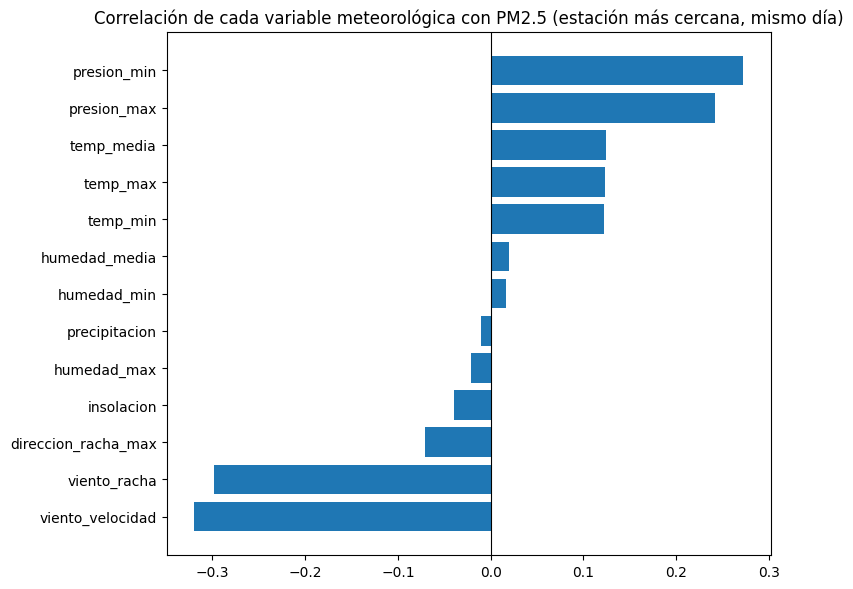

viento_velocidad      -0.319623
viento_racha          -0.298404
direccion_racha_max   -0.070948
insolacion            -0.039096
humedad_max           -0.020997
precipitacion         -0.010439
humedad_min            0.016797
humedad_media          0.019593
temp_min               0.121614
temp_max               0.122960
temp_media             0.124468
presion_max            0.241519
presion_min            0.272102
Name: pm25, dtype: float64


In [12]:
# ============================================================
# CORRELACIÓN EMPÍRICA PM2.5 vs METEOROLOGÍA (ESTACIÓN MÁS CERCANA)
# ============================================================

exploracion = pm25.merge(meteo_por_estacion, on=["estacion", "fecha"], how="left")

cols_meteo = [c for c in meteo_por_estacion.columns if c not in ("estacion", "fecha")]
corr_meteo = exploracion[["pm25"] + cols_meteo].corr()["pm25"].drop("pm25").sort_values()

plt.figure(figsize=(8, 6))
plt.barh(corr_meteo.index, corr_meteo.values)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlación de cada variable meteorológica con PM2.5 (estación más cercana, mismo día)")
plt.tight_layout()
plt.show()

print(corr_meteo)


El viento (velocidad y racha) muestra la correlación negativa más fuerte —coherente con su papel dispersor de partículas— y la presión muestra correlación positiva —coherente con episodios anticiclónicos de aire estancado—. Estas variables se priorizan explícitamente en el modelo, sin descartar el resto de variables meteorológicas disponibles.


## 3. Contaminantes cruzados: selección basada en correlación propia

Se evalúa la correlación de PM2.5 con el resto de contaminantes disponibles en la capa `enriched` (NO2, PM10, O3), a nivel de promedio diario ciudad, para decidir cuáles aportan señal real antes de incorporarlos como features.


In [13]:
# ============================================================
# CORRELACIÓN CRUZADA ENTRE CONTAMINANTES
# ============================================================

todos_contaminantes = con.execute(
    """
    SELECT fecha, magnitud, AVG(uom_value) AS valor
    FROM read_parquet(?)
    GROUP BY fecha, magnitud
    """,
    [str(CALIDAD_AIRE_PATH)]
).fetchdf()

todos_contaminantes["fecha"] = pd.to_datetime(todos_contaminantes["fecha"])

pivot_contam = (
    todos_contaminantes
    .pivot(index="fecha", columns="magnitud", values="valor")
    .rename(columns={8: "NO2", 9: "PM25", 10: "PM10", 14: "O3"})
)

cols_disponibles = [c for c in ["NO2", "PM25", "PM10", "O3"] if c in pivot_contam.columns]

display(pivot_contam[cols_disponibles].corr())


magnitud,NO2,PM25,PM10,O3
magnitud,,,,
NO2,1.000000,0.520079,0.309419,-0.737480
PM25,0.520079,1.000000,0.798967,-0.278349
PM10,0.309419,0.798967,1.000000,-0.099829
O3,-0.737480,-0.278349,-0.099829,1.000000


**Decisión:** se incorporan **PM10** (correlación ≈ 0.80, relación física directa: PM2.5 es un subconjunto de PM10) y **NO2** (correlación ≈ 0.52, trazador de tráfico/combustión) como features, siempre en versión **con retardo (lag)**, nunca del mismo día, para no introducir información no disponible en el momento de la predicción. **O3** se descarta: correlación débil y cobertura de estaciones insuficiente (comprobado en el análisis de disponibilidad de datos del proyecto).


## 4. Construcción del dataset de modelado

Se construye el dataset final combinando: PM2.5 por estación, meteorología ciudad, contaminantes cruzados (NO2, PM10), variables de calendario, lags, medias móviles y un lag espacial (PM2.5 medio del resto de la ciudad).


In [14]:
# ============================================================
# CARGA DE CONTAMINANTES CRUZADOS (NO2, PM10, O3) — VALOR DE LA PROPIA ESTACIÓN
# (a diferencia de la meteorología, estos contaminantes se miden en la misma
#  red de estaciones que PM2.5, así que se usa directamente el valor medido
#  en cada estación, sin necesidad de buscar ninguna estación "más cercana")
# ============================================================

def _cargar_contaminante_propio(con, path, magnitud, nombre_columna):
    df_c = con.execute(
        """
        SELECT fecha, estacion, uom_value AS valor
        FROM read_parquet(?)
        WHERE magnitud = ?
        """,
        [str(path), magnitud]
    ).fetchdf()
    df_c["fecha"] = pd.to_datetime(df_c["fecha"])
    return df_c.rename(columns={"valor": nombre_columna})


no2_propio = _cargar_contaminante_propio(con, CALIDAD_AIRE_PATH, MAGNITUD_NO2, "no2")
pm10_propio = _cargar_contaminante_propio(con, CALIDAD_AIRE_PATH, MAGNITUD_PM10, "pm10")
o3_propio = _cargar_contaminante_propio(con, CALIDAD_AIRE_PATH, MAGNITUD_O3, "o3")

# Comprobación de cobertura: no todas las estaciones que miden PM2.5 tienen
# por qué medir también O3 (a diferencia de NO2 y PM10). Donde falte, sus
# lags/rolling quedarán en NaN y XGBoost los tratará de forma nativa (ver
# celda de limpieza más adelante) — punto a validar con el equipo.
estaciones_pm25 = set(pm25["estacion"].unique())
faltan_no2 = estaciones_pm25 - set(no2_propio["estacion"].unique())
faltan_pm10 = estaciones_pm25 - set(pm10_propio["estacion"].unique())
faltan_o3 = estaciones_pm25 - set(o3_propio["estacion"].unique())

print("NO2 propio:", no2_propio.shape, " | PM10 propio:", pm10_propio.shape, " | O3 propio:", o3_propio.shape)
print("Estaciones PM2.5 sin NO2 propio:", faltan_no2 if faltan_no2 else "ninguna")
print("Estaciones PM2.5 sin PM10 propio:", faltan_pm10 if faltan_pm10 else "ninguna")
print("Estaciones PM2.5 sin O3 propio:", faltan_o3 if faltan_o3 else "ninguna")


NO2 propio: (40194, 3)  | PM10 propio: (23751, 3)  | O3 propio: (23751, 3)
Estaciones PM2.5 sin NO2 propio: ninguna
Estaciones PM2.5 sin PM10 propio: ninguna
Estaciones PM2.5 sin O3 propio: {np.int64(38), np.int64(47), np.int64(48), np.int64(50), np.int64(56), np.int64(57)}


In [15]:
# ============================================================
# LAG ESPACIAL: PM2.5 MEDIO DEL RESTO DE LA CIUDAD (EXCLUYENDO LA PROPIA ESTACIÓN)
# ============================================================

pm25_total_dia = pm25.groupby("fecha")["pm25"].agg(["sum", "count"]).rename(
    columns={"sum": "suma_dia", "count": "n_estaciones_dia"}
)

pm25_con_resto = pm25.merge(pm25_total_dia, on="fecha", how="left")

# Media del resto de estaciones = (suma total - valor propio) / (n - 1)
pm25_con_resto["pm25_resto_ciudad"] = (
    (pm25_con_resto["suma_dia"] - pm25_con_resto["pm25"])
    / (pm25_con_resto["n_estaciones_dia"] - 1)
)

pm25_con_resto = pm25_con_resto.drop(columns=["suma_dia", "n_estaciones_dia"])

display(pm25_con_resto.head())


,fecha,estacion,pm25,es_laborable_madrid_ciudad,pm25_resto_ciudad
0,2020-01-01,8,28.250000,False,31.752728
1,2020-01-02,8,19.083333,True,24.255994
2,2020-01-03,8,37.500000,True,37.533013
3,2020-01-04,8,6.652174,False,8.903714
4,2020-01-05,8,8.041667,False,13.225034


In [16]:
# ============================================================
# ENSAMBLADO DEL DATASET
# ============================================================

metadata_espacial = estaciones_aire[
    ["ESTACION", "LATITUD_G", "LONGITUD_G", "ALTITUD", "TIPO_ESTACION"]
].rename(columns={"ESTACION": "estacion"})

df = (
    pm25_con_resto
    .merge(meteo_por_estacion_lag, on=["estacion", "fecha"], how="left")
    .merge(no2_propio, on=["estacion", "fecha"], how="left")
    .merge(pm10_propio, on=["estacion", "fecha"], how="left")
    .merge(o3_propio, on=["estacion", "fecha"], how="left")
    .merge(metadata_espacial, on="estacion", how="left")
    .sort_values(["estacion", "fecha"])
    .reset_index(drop=True)
)

# One-hot encoding de TIPO_ESTACION (TRAFICO / FONDO)
df = pd.get_dummies(df, columns=["TIPO_ESTACION"], prefix="tipo_estacion")
cols_tipo_estacion = [c for c in df.columns if c.startswith("tipo_estacion_")]

print("Shape tras ensamblado:", df.shape)
print("Columnas de tipo de estación creadas:", cols_tipo_estacion)
print("\nNulos por columna:")
print(df.isna().sum()[df.isna().sum() > 0])

display(df.head())


Shape tras ensamblado: (14616, 26)
Columnas de tipo de estación creadas: ['tipo_estacion_FONDO', 'tipo_estacion_TRAFICO']

Nulos por columna:
direccion_racha_max        8
humedad_max                8
humedad_media              8
humedad_min                8
insolacion                 8
precipitacion              8
presion_max                8
presion_min                8
temp_max                   8
temp_media                 8
temp_min                   8
viento_racha               8
viento_velocidad           8
o3                     10962
dtype: int64


,fecha,estacion,pm25,es_laborable_madrid_ciudad,pm25_resto_ciudad,direccion_racha_max,humedad_max,humedad_media,humedad_min,insolacion,precipitacion,presion_max,presion_min,temp_max,temp_media,temp_min,viento_racha,viento_velocidad,no2,pm10,o3,LATITUD_G,LONGITUD_G,ALTITUD,tipo_estacion_FONDO,tipo_estacion_TRAFICO
0,2020-01-01,8,28.250000,False,31.752728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.666667,36.208333,5.266250,40.42167,-3.68222,672,False,True
1,2020-01-02,8,19.083333,True,24.255994,50.0,80.0,65.0,48.0,8.7,0.0,954.2,952.0,11.2,6.6,1.9,3.3,0.3,68.083333,29.000000,4.294583,40.42167,-3.68222,672,False,True
2,2020-01-03,8,37.500000,True,37.533013,230.0,89.0,77.0,63.0,8.3,0.0,953.7,951.0,10.5,6.0,1.6,3.3,0.6,73.458333,50.666667,1.887500,40.42167,-3.68222,672,False,True
3,2020-01-04,8,6.652174,False,8.903714,95.0,89.0,83.0,74.0,1.4,0.0,954.8,952.2,6.0,3.8,1.5,5.0,0.6,42.347826,9.913043,25.960000,40.42167,-3.68222,672,False,True
4,2020-01-05,8,8.041667,False,13.225034,40.0,77.0,58.0,44.0,8.9,0.0,955.9,952.5,11.2,7.0,2.8,9.4,2.5,51.291667,14.125000,19.327083,40.42167,-3.68222,672,False,True


### Variables de calendario

Dado que el análisis exploratorio mostró un efecto muy débil del día de la semana (variación de apenas ~1 µg/m³ entre lunes y domingo) pero un patrón mensual **bimodal** (invierno y verano altos, primavera baja), se usa codificación cíclica del mes y se incluye el día de la semana como variable adicional para que el modelo decida si aporta algo, sin asumir a priori que el patrón de tráfico laboral domina la variabilidad de PM2.5.


In [17]:
# ============================================================
# VARIABLES DE CALENDARIO
# ============================================================

df["mes"] = df["fecha"].dt.month
df["dia_semana"] = df["fecha"].dt.dayofweek  # 0 = lunes

df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)

display(df[["fecha", "mes", "mes_sin", "mes_cos", "dia_semana", "es_laborable_madrid_ciudad"]].head())


,fecha,mes,mes_sin,mes_cos,dia_semana,es_laborable_madrid_ciudad
0,2020-01-01,1,0.5,0.866025,2,False
1,2020-01-02,1,0.5,0.866025,3,True
2,2020-01-03,1,0.5,0.866025,4,True
3,2020-01-04,1,0.5,0.866025,5,False
4,2020-01-05,1,0.5,0.866025,6,False


### Lags, medias móviles y contaminantes cruzados

Todas las variables temporales se calculan **por estación**, respetando el orden cronológico, para no mezclar información entre estaciones distintas.


In [18]:
# ============================================================
# LAGS DE PM2.5 (TARGET)
# Estándar del equipo: lags 1, 2 y 7 días.
# ============================================================

LAGS = [1, 2, 7]

for lag in LAGS:
    df[f"pm25_lag_{lag}"] = df.groupby("estacion")["pm25"].shift(lag)


In [19]:
# ============================================================
# MEDIAS Y DESVIACIONES MÓVILES (ROLLING) DE PM2.5
# Se calculan sobre valores YA retardados (shift(1) antes del rolling) para
# que la ventana no incluya el valor del propio día objetivo.
# ============================================================

pm25_shifted = df.groupby("estacion")["pm25"].shift(1)

df["pm25_roll_mean_3"] = (
    pm25_shifted.groupby(df["estacion"]).rolling(3, min_periods=3).mean().reset_index(level=0, drop=True)
)
df["pm25_roll_std_3"] = (
    pm25_shifted.groupby(df["estacion"]).rolling(3, min_periods=3).std().reset_index(level=0, drop=True)
)
df["pm25_roll_mean_7"] = (
    pm25_shifted.groupby(df["estacion"]).rolling(7, min_periods=7).mean().reset_index(level=0, drop=True)
)
df["pm25_roll_std_7"] = (
    pm25_shifted.groupby(df["estacion"]).rolling(7, min_periods=7).std().reset_index(level=0, drop=True)
)

display(
    df[["fecha","estacion","pm25","pm25_lag_1","pm25_roll_mean_3","pm25_roll_mean_7","pm25_roll_std_7"]].head(12)
)


,fecha,estacion,pm25,pm25_lag_1,pm25_roll_mean_3,pm25_roll_mean_7,pm25_roll_std_7
0,2020-01-01,8,28.250000,NaN,NaN,NaN,NaN
1,2020-01-02,8,19.083333,28.250000,NaN,NaN,NaN
2,2020-01-03,8,37.500000,19.083333,NaN,NaN,NaN
3,2020-01-04,8,6.652174,37.500000,28.277778,NaN,NaN
4,2020-01-05,8,8.041667,6.652174,21.078502,NaN,NaN
5,2020-01-06,8,14.166667,8.041667,17.397947,NaN,NaN
6,2020-01-07,8,17.761905,14.166667,9.620169,NaN,NaN
7,2020-01-08,8,18.666667,17.761905,13.323413,18.779392,10.991865
8,2020-01-09,8,19.458333,18.666667,16.865079,17.410345,10.182721
9,2020-01-10,8,6.583333,19.458333,18.628968,17.463916,10.193970


In [20]:
# ============================================================
# LAGS Y ROLLING DE CONTAMINANTES CRUZADOS (NO2, PM10, O3 PROPIOS)
# Y LAG DEL "RESTO DE CIUDAD"
# Estándar del equipo: lags 1, 2, 7 días + medias móviles 3 y 7 días,
# para cada contaminante cruzado disponible.
# ============================================================

df["pm25_resto_ciudad_lag_1"] = df.groupby("estacion")["pm25_resto_ciudad"].shift(1)

CONTAMINANTES_CRUZADOS = ["no2", "pm10", "o3"]

for col in CONTAMINANTES_CRUZADOS:
    # Lags
    for lag in [1, 2, 7]:
        df[f"{col}_lag_{lag}"] = df.groupby("estacion")[col].shift(lag)

    # Rolling (sobre valores ya retardados 1 día, para no filtrar el propio día objetivo)
    col_shifted = df.groupby("estacion")[col].shift(1)
    df[f"{col}_roll_mean_3"] = (
        col_shifted.groupby(df["estacion"]).rolling(3, min_periods=3).mean().reset_index(level=0, drop=True)
    )
    df[f"{col}_roll_mean_7"] = (
        col_shifted.groupby(df["estacion"]).rolling(7, min_periods=7).mean().reset_index(level=0, drop=True)
    )

display(
    df[[
        "fecha", "estacion", "pm25_resto_ciudad_lag_1",
        "no2_lag_1", "pm10_lag_1", "o3_lag_1", "o3_roll_mean_7",
    ]].head(10)
)

print("\nNulos en columnas de O3 (por baja cobertura de estaciones):")
cols_o3 = [c for c in df.columns if c.startswith("o3_")]
print(df[cols_o3].isna().sum())


,fecha,estacion,pm25_resto_ciudad_lag_1,no2_lag_1,pm10_lag_1,o3_lag_1,o3_roll_mean_7
0,2020-01-01,8,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,8,31.752728,65.666667,36.208333,5.266250,NaN
2,2020-01-03,8,24.255994,68.083333,29.000000,4.294583,NaN
3,2020-01-04,8,37.533013,73.458333,50.666667,1.887500,NaN
4,2020-01-05,8,8.903714,42.347826,9.913043,25.960000,NaN
5,2020-01-06,8,13.225034,51.291667,14.125000,19.327083,NaN
6,2020-01-07,8,17.314326,60.083333,22.291667,11.130833,NaN
7,2020-01-08,8,23.673590,85.130435,31.238095,3.667273,10.219075
8,2020-01-09,8,22.766133,99.791667,37.333333,3.654167,9.988777
9,2020-01-10,8,21.269158,77.958333,32.125000,7.043333,10.381456



Nulos en columnas de O3 (por baja cobertura de estaciones):
o3_lag_1          10964
o3_lag_2          10966
o3_lag_7          10976
o3_roll_mean_3    10968
o3_roll_mean_7    10976
dtype: int64


In [21]:
# ============================================================
# LIMPIEZA: ELIMINAR FILAS SIN HISTÓRICO SUFICIENTE
# (el mayor requisito es el rolling de 7 días -> primeras filas de cada
#  estación se descartan)
#
# NOTA: las columnas de O3 (o3_lag_*, o3_roll_*) se EXCLUYEN de este criterio
# a propósito. Solo 2 de las 8 estaciones que miden PM2.5 tienen O3 propio,
# así que exigir O3 no nulo eliminaría la mayor parte del dataset. En vez de
# eso, se dejan esos NaN tal cual: XGBoost admite valores nulos de forma
# nativa y aprende una dirección por defecto para ellos durante el split.
# ⚠️ VALIDAR CON EL EQUIPO: si el criterio acordado es otro (p. ej. imputar
# con 0, con la media, o excluir O3 directamente del modelo), avisar para
# ajustar este paso.
# ============================================================

cols_o3 = [c for c in df.columns if c.startswith("o3_")]
cols_temporales = [
    c for c in df.columns
    if ("_lag_" in c or "_roll_" in c) and c not in cols_o3
]

print("Filas antes de limpiar:", len(df))
df_modelo = df.dropna(subset=cols_temporales).reset_index(drop=True)
print("Filas después de limpiar:", len(df_modelo))
print("Nulos restantes en el dataset (incluye O3, a propósito):", df_modelo.isna().sum().sum())
print("  - de los cuales en columnas de O3:", df_modelo[cols_o3].isna().sum().sum())


Filas antes de limpiar: 14616
Filas después de limpiar: 14560
Nulos restantes en el dataset (incluye O3, a propósito): 65520
  - de los cuales en columnas de O3: 54600


In [22]:
# ============================================================
# TARGET EN ESCALA LOG (log1p) — ver sección 1
# ============================================================

df_modelo["pm25_log"] = np.log1p(df_modelo["pm25"])

display(df_modelo[["pm25", "pm25_log"]].describe())


,pm25,pm25_log
count,14560.000000,14560.000000
mean,9.332533,2.190860
std,6.110872,0.534475
min,1.000000,0.693147
25%,5.166667,1.819158
50%,8.125000,2.211018
75%,11.800906,2.549516
max,84.291667,4.446077


In [23]:
# ============================================================
# GUARDAR DATASET DE MODELADO
# ============================================================

OUTPUT_PATH = ROOT / "data" / "modeling" / "dataset_pm25_propio.parquet"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_modelo.to_parquet(OUTPUT_PATH, index=False)

print("Dataset guardado:", OUTPUT_PATH)
print("Shape final:", df_modelo.shape)
print("\nColumnas disponibles:")
print(df_modelo.columns.tolist())


Dataset guardado: /home/claude/TFM/data/modeling/dataset_pm25_propio.parquet
Shape final: (14560, 54)

Columnas disponibles:
['fecha', 'estacion', 'pm25', 'es_laborable_madrid_ciudad', 'pm25_resto_ciudad', 'direccion_racha_max', 'humedad_max', 'humedad_media', 'humedad_min', 'insolacion', 'precipitacion', 'presion_max', 'presion_min', 'temp_max', 'temp_media', 'temp_min', 'viento_racha', 'viento_velocidad', 'no2', 'pm10', 'o3', 'LATITUD_G', 'LONGITUD_G', 'ALTITUD', 'tipo_estacion_FONDO', 'tipo_estacion_TRAFICO', 'mes', 'dia_semana', 'mes_sin', 'mes_cos', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_7', 'pm25_roll_mean_3', 'pm25_roll_std_3', 'pm25_roll_mean_7', 'pm25_roll_std_7', 'pm25_resto_ciudad_lag_1', 'no2_lag_1', 'no2_lag_2', 'no2_lag_7', 'no2_roll_mean_3', 'no2_roll_mean_7', 'pm10_lag_1', 'pm10_lag_2', 'pm10_lag_7', 'pm10_roll_mean_3', 'pm10_roll_mean_7', 'o3_lag_1', 'o3_lag_2', 'o3_lag_7', 'o3_roll_mean_3', 'o3_roll_mean_7', 'pm25_log']


## 5. Selección de variables predictoras y tipado

`estacion` se convierte a tipo categórico real (no entero ordinal), para que XGBoost la trate como una identidad discreta y no como una magnitud con orden.


In [24]:
# ============================================================
# FEATURES Y TARGET
# ============================================================

TARGET = "pm25_log"

FEATURES = [
    # Meteorología (T−1, ver METEO_LAG_DAYS)
    "temp_media", "temp_min", "temp_max",
    "humedad_media", "humedad_min", "humedad_max",
    "insolacion", "precipitacion",
    "presion_max", "presion_min",
    "viento_velocidad", "viento_racha", "direccion_racha_max",

    # Calendario (día objetivo, T+1)
    "es_laborable_madrid_ciudad", "dia_semana", "mes_sin", "mes_cos",

    # Estación (todas pedidas por el estándar)
    "estacion",                                  # identidad (categórica)
    "LATITUD_G", "LONGITUD_G", "ALTITUD",
    *cols_tipo_estacion,                          # tipo_estacion_TRAFICO / _FONDO (one-hot)

    # Histórico del contaminante objetivo (PM2.5): lags 1, 2, 7 + rolling 3, 7
    "pm25_lag_1", "pm25_lag_2", "pm25_lag_7",
    "pm25_roll_mean_3", "pm25_roll_std_3",
    "pm25_roll_mean_7", "pm25_roll_std_7",
    # ELIMINADA: pm25_resto_ciudad_lag_1 (única variable realmente fuera del estándar)

    # Histórico de otros contaminantes: lags 1, 2, 7 + rolling 3, 7
    "no2_lag_1", "no2_lag_2", "no2_lag_7", "no2_roll_mean_3", "no2_roll_mean_7",
    "pm10_lag_1", "pm10_lag_2", "pm10_lag_7", "pm10_roll_mean_3", "pm10_roll_mean_7",
    "o3_lag_1", "o3_lag_2", "o3_lag_7", "o3_roll_mean_3", "o3_roll_mean_7",
]

FEATURES = [f for f in FEATURES if f in df_modelo.columns]

X = df_modelo[FEATURES].copy()
X["estacion"] = X["estacion"].astype("category")

y = df_modelo[TARGET].copy()

print("N features:", len(FEATURES))
print("Nulos en X (excluyendo columnas O3, esperado):")
cols_no_o3 = [f for f in FEATURES if not f.startswith("o3_")]
print("  - fuera de O3:", X[cols_no_o3].isna().sum().sum())
print("  - en O3:", X[[f for f in FEATURES if f.startswith('o3_')]].isna().sum().sum())
print("Nulos en y:", y.isna().sum())


N features: 45
Nulos en X (excluyendo columnas O3, esperado):
  - fuera de O3: 0
  - en O3: 54600
Nulos en y: 0


In [25]:
# Los nulos en columnas de O3 son esperados y aceptados (ver nota en la
# celda de limpieza); el resto de columnas debe estar completo.
cols_no_o3 = [f for f in FEATURES if not f.startswith("o3_") and f != "estacion"]
assert X[cols_no_o3].isna().sum().sum() == 0
assert y.isna().sum() == 0
print("Comprobación OK.")


Comprobación OK.


## 6. División temporal

Se mantiene una división por años (train / validación / test) porque es la forma estadísticamente correcta de evaluar un modelo de series temporales — evita que información futura se filtre al entrenamiento.


In [26]:
# ============================================================
# SPLIT TEMPORAL: TRAIN / VALIDATION / TEST
# ============================================================

train_mask = df_modelo["fecha"] < "2023-01-01"
val_mask = (df_modelo["fecha"] >= "2023-01-01") & (df_modelo["fecha"] < "2024-01-01")
test_mask = df_modelo["fecha"] >= "2024-01-01"

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[val_mask], y.loc[val_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
assert df_modelo.loc[train_mask, "fecha"].max() < df_modelo.loc[val_mask, "fecha"].min()
assert df_modelo.loc[val_mask, "fecha"].max() < df_modelo.loc[test_mask, "fecha"].min()
print("Split temporal correcto.")


Train: (8712, 45) | Val: (2920, 45) | Test: (2928, 45)
Split temporal correcto.


## 7. Baselines

Se comparan **dos** baselines, no solo persistencia: la persistencia puede ser engañosamente buena en series muy autocorrelacionadas, así que se añade también una media móvil de 7 días como referencia adicional, más robusta frente a ruido diario.


In [27]:
# ============================================================
# BASELINES (en escala original, no log)
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_test_original = df_modelo.loc[test_mask, "pm25"]

# Baseline 1: persistencia (lag 1)
pred_persistencia = df_modelo.loc[test_mask, "pm25_lag_1"]

# Baseline 2: media móvil de 7 días
pred_media_movil = df_modelo.loc[test_mask, "pm25_roll_mean_7"]

baselines = pd.DataFrame([
    {
        "modelo": "Persistencia (lag 1)",
        "MAE": mean_absolute_error(y_test_original, pred_persistencia),
        "RMSE": np.sqrt(mean_squared_error(y_test_original, pred_persistencia)),
        "R2": r2_score(y_test_original, pred_persistencia),
    },
    {
        "modelo": "Media móvil 7 días",
        "MAE": mean_absolute_error(y_test_original, pred_media_movil),
        "RMSE": np.sqrt(mean_squared_error(y_test_original, pred_media_movil)),
        "R2": r2_score(y_test_original, pred_media_movil),
    },
])

display(baselines)


,modelo,MAE,RMSE,R2
0,Persistencia (lag 1),2.944384,4.343079,0.334908
1,Media móvil 7 días,3.763513,5.160767,0.060894


## 8. Modelo XGBoost

Se entrena directamente sobre la variable objetivo en **escala log**. Para la búsqueda de hiperparámetros se usa `early_stopping_rounds` sobre el conjunto de validación (en vez de recorrer una rejilla fija de número de árboles), lo que permite que cada combinación de hiperparámetros determine automáticamente su número óptimo de árboles y resulta más eficiente que una búsqueda exhaustiva.


In [28]:
# ============================================================
# BÚSQUEDA DE HIPERPARÁMETROS CON EARLY STOPPING
# ============================================================

from xgboost import XGBRegressor
import itertools

param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

combinaciones = list(itertools.product(*param_grid.values()))
claves = list(param_grid.keys())

print("Combinaciones a evaluar:", len(combinaciones))

resultados_tuning = []

for i, valores in enumerate(combinaciones, start=1):
    params = dict(zip(claves, valores))

    modelo = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        early_stopping_rounds=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        enable_categorical=True,
        **params,
    )

    modelo.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    pred_val_log = modelo.predict(X_val)
    pred_val = np.expm1(pred_val_log)
    y_val_original = df_modelo.loc[val_mask, "pm25"]

    mae = mean_absolute_error(y_val_original, pred_val)
    rmse = np.sqrt(mean_squared_error(y_val_original, pred_val))
    r2 = r2_score(y_val_original, pred_val)

    resultados_tuning.append({
        **params,
        "best_iteration": modelo.best_iteration,
        "MAE": mae, "RMSE": rmse, "R2": r2,
    })

    if i % 6 == 0:
        print(f"Completadas {i}/{len(combinaciones)}")

resultados_tuning = pd.DataFrame(resultados_tuning).sort_values("MAE").reset_index(drop=True)
display(resultados_tuning.head(10))


Combinaciones a evaluar: 36


Completadas 6/36


Completadas 12/36


Completadas 18/36


Completadas 24/36


Completadas 30/36


Completadas 36/36


,max_depth,learning_rate,subsample,colsample_bytree,best_iteration,MAE,RMSE,R2
0,4,0.05,0.8,0.8,164,2.923081,4.413627,0.480761
1,4,0.03,0.8,0.8,261,2.929340,4.410074,0.481596
2,4,0.10,1.0,0.8,75,2.935091,4.428384,0.477283
3,6,0.03,0.8,1.0,132,2.937453,4.381643,0.488259
4,6,0.03,0.8,0.8,198,2.937959,4.416142,0.480169
5,6,0.10,0.8,1.0,28,2.940428,4.429545,0.477009
6,8,0.03,0.8,1.0,152,2.941035,4.376305,0.489505
7,4,0.10,1.0,1.0,85,2.942839,4.418634,0.479582
8,4,0.03,1.0,0.8,293,2.942985,4.453385,0.471364
9,6,0.05,1.0,0.8,138,2.943673,4.408343,0.482003


In [29]:
# ============================================================
# MEJOR CONFIGURACIÓN (evaluada en escala original vía expm1)
# ============================================================

mejores_params = resultados_tuning.iloc[0][claves].to_dict()
mejor_n_estimators = int(resultados_tuning.iloc[0]["best_iteration"]) + 1

print("Mejores hiperparámetros:", mejores_params)
print("Número de árboles óptimo (early stopping):", mejor_n_estimators)


Mejores hiperparámetros: {'max_depth': 4.0, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
Número de árboles óptimo (early stopping): 165


## 9. Importancia de variables (modelo de validación)


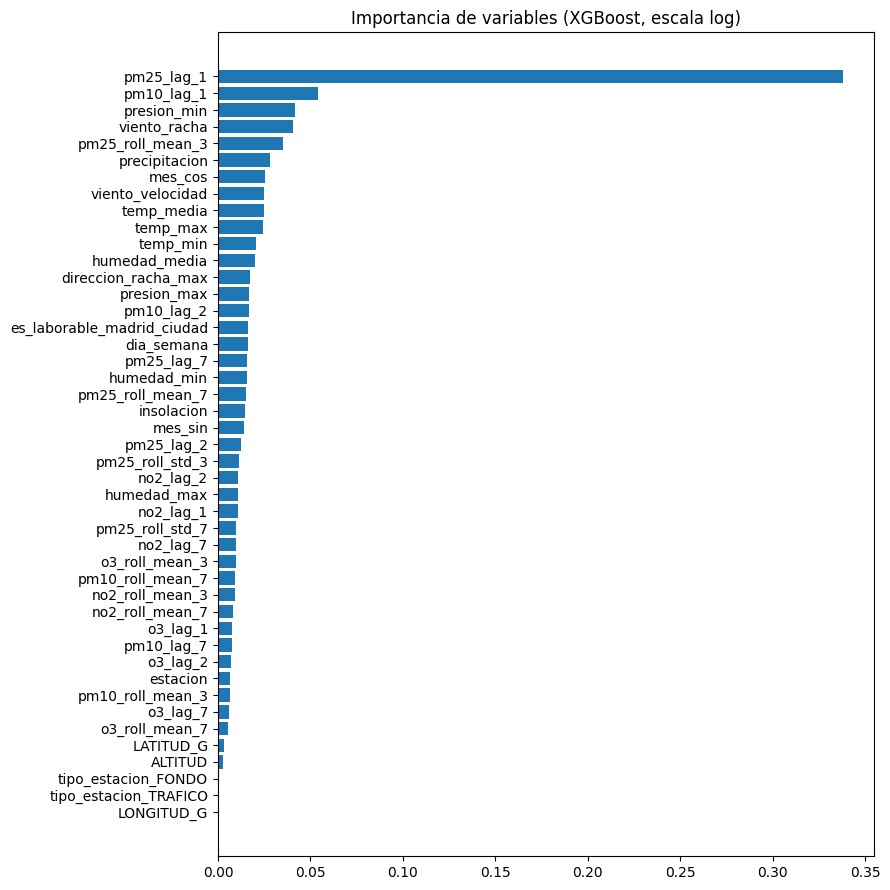

,feature,importancia
23,pm25_lag_1,0.338037
35,pm10_lag_1,0.053885
9,presion_min,0.041641
11,viento_racha,0.040644
26,pm25_roll_mean_3,0.034949
7,precipitacion,0.028130
16,mes_cos,0.025372
10,viento_velocidad,0.024908
0,temp_media,0.024906
2,temp_max,0.024576


In [30]:
# ============================================================
# REENTRENAR CON MEJOR CONFIGURACIÓN SOBRE TRAIN, PARA INSPECCIÓN
# ============================================================

modelo_val = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=mejor_n_estimators,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    enable_categorical=True,
    **{k: (int(v) if k == "max_depth" else v) for k, v in mejores_params.items()},
)

modelo_val.fit(X_train, y_train)

importancias = pd.DataFrame({
    "feature": FEATURES,
    "importancia": modelo_val.feature_importances_,
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(9, 9))
plt.barh(importancias["feature"][::-1], importancias["importancia"][::-1])
plt.title("Importancia de variables (XGBoost, escala log)")
plt.tight_layout()
plt.show()

display(importancias)


## 10. Entrenamiento y evaluación final (test 2024)

Se reentrena con 2020–2023 (train + validación) usando la configuración ganadora, y se evalúa una única vez sobre 2024.


In [31]:
# ============================================================
# REENTRENAMIENTO FINAL: TRAIN + VALIDACIÓN (2020-2023)
# ============================================================

train_final_mask = df_modelo["fecha"] < "2024-01-01"

X_train_final = X.loc[train_final_mask]
y_train_final = y.loc[train_final_mask]

modelo_final = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=mejor_n_estimators,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    enable_categorical=True,
    **{k: (int(v) if k == "max_depth" else v) for k, v in mejores_params.items()},
)

modelo_final.fit(X_train_final, y_train_final)

print("Modelo final entrenado correctamente.")
print("Periodo de entrenamiento:",
      df_modelo.loc[train_final_mask, "fecha"].min(), "→",
      df_modelo.loc[train_final_mask, "fecha"].max())


Modelo final entrenado correctamente.
Periodo de entrenamiento: 2020-01-08 00:00:00 → 2023-12-31 00:00:00


In [32]:
# ============================================================
# EVALUACIÓN FINAL SOBRE TEST 2024 (deshaciendo log1p)
# ============================================================

pred_test_log = modelo_final.predict(X_test)
pred_test = np.expm1(pred_test_log)

mae_test = mean_absolute_error(y_test_original, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_original, pred_test))
r2_test = r2_score(y_test_original, pred_test)
# Sesgo medio: positivo = el modelo tiende a SUBESTIMAR (predicción < real);
# negativo = tiende a SOBREESTIMAR (predicción > real).
sesgo_test = (y_test_original - pred_test).mean()

print("XGBOOST FINAL (PM2.5, escala log) - TEST 2024")
print("-----------------------------------------------")
print(f"MAE:   {mae_test:.3f} µg/m³")
print(f"RMSE:  {rmse_test:.3f} µg/m³")
print(f"R²:    {r2_test:.3f}")
print(f"Sesgo: {sesgo_test:+.3f} µg/m³ "
      f"({'subestima' if sesgo_test > 0 else 'sobreestima'} en promedio)")


XGBOOST FINAL (PM2.5, escala log) - TEST 2024
-----------------------------------------------
MAE:   2.449 µg/m³
RMSE:  3.587 µg/m³
R²:    0.546
Sesgo: +0.143 µg/m³ (subestima en promedio)


In [33]:
# ============================================================
# COMPARACIÓN FINAL: BASELINES vs XGBOOST (incluye sesgo medio)
# ============================================================

sesgo_persistencia = (y_test_original - pred_persistencia).mean()
sesgo_media_movil = (y_test_original - pred_media_movil).mean()

baselines_con_sesgo = baselines.copy()
baselines_con_sesgo["Sesgo"] = [sesgo_persistencia, sesgo_media_movil]

comparacion_final = pd.concat([
    baselines_con_sesgo,
    pd.DataFrame([{
        "modelo": "XGBoost (log-target, propio)",
        "MAE": mae_test, "RMSE": rmse_test, "R2": r2_test, "Sesgo": sesgo_test,
    }])
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

display(comparacion_final)

mejor_baseline_mae = baselines["MAE"].min()
mejora = (mejor_baseline_mae - mae_test) / mejor_baseline_mae * 100
print(f"\nReducción de MAE frente al mejor baseline: {mejora:.2f}%")


,modelo,MAE,RMSE,R2,Sesgo
0,"XGBoost (log-target, propio)",2.448713,3.587353,0.546231,0.142729
1,Persistencia (lag 1),2.944384,4.343079,0.334908,0.000869
2,Media móvil 7 días,3.763513,5.160767,0.060894,-0.121286



Reducción de MAE frente al mejor baseline: 16.83%


## 11. Análisis de errores


In [34]:
# ============================================================
# ERROR POR RANGO DE CONCENTRACIÓN
# ============================================================

evaluacion = df_modelo.loc[test_mask, ["fecha", "estacion", "pm25"]].copy()
evaluacion["prediccion"] = pred_test
evaluacion["error"] = evaluacion["pm25"] - evaluacion["prediccion"]
evaluacion["error_absoluto"] = evaluacion["error"].abs()

evaluacion["rango_pm25"] = pd.cut(
    evaluacion["pm25"],
    bins=[0, 5, 10, 15, 25, 50, np.inf],
    labels=["0-5", "5-10", "10-15", "15-25", "25-50", ">50"],
    include_lowest=True,
)

error_por_rango = evaluacion.groupby("rango_pm25", observed=True).agg(
    n=("pm25", "size"),
    pm25_real_medio=("pm25", "mean"),
    MAE=("error_absoluto", "mean"),
)

display(error_por_rango)


,n,pm25_real_medio,MAE
rango_pm25,,,
0-5,823,3.426947,1.693632
5-10,1131,7.251890,1.856404
10-15,629,12.087887,2.488955
15-25,311,18.553277,5.265561
25-50,34,28.651786,13.918700


In [35]:
# ============================================================
# ¿SIGUE FALLANDO EN EL EPISODIO DE CALIMA?
# ============================================================

if dia_pico in evaluacion["fecha"].values:
    print(evaluacion[evaluacion["fecha"] == dia_pico])
else:
    print(f"El episodio de calima ({dia_pico.date()}) no está en el conjunto de test 2024;")
    print("se revisan aquí los peores errores absolutos del test para comprobar si hay eventos similares:")
    display(evaluacion.nlargest(10, "error_absoluto"))


El episodio de calima (2022-03-15) no está en el conjunto de test 2024;
se revisan aquí los peores errores absolutos del test para comprobar si hay eventos similares:


,fecha,estacion,pm25,prediccion,error,error_absoluto,rango_pm25
12533,2024-06-08,56,39.416667,11.806899,27.609768,27.609768,25-50
9013,2024-10-06,48,33.458333,9.134342,24.323991,24.323991,25-50
5373,2024-10-06,38,28.708333,5.794109,22.914224,22.914224,25-50
5398,2024-10-31,38,37.750000,16.698597,21.051403,21.051403,25-50
1733,2024-10-06,8,29.958333,9.536908,20.421425,20.421425,25-50
9038,2024-10-31,48,36.125000,16.208574,19.916426,19.916426,25-50
10833,2024-10-06,50,23.791667,5.006595,18.785072,18.785072,15-25
5442,2024-12-14,38,27.625000,9.019980,18.605020,18.605020,25-50
1613,2024-06-08,8,32.583333,14.729134,17.854200,17.854200,25-50
10858,2024-10-31,50,32.833333,15.020563,17.812770,17.812770,25-50


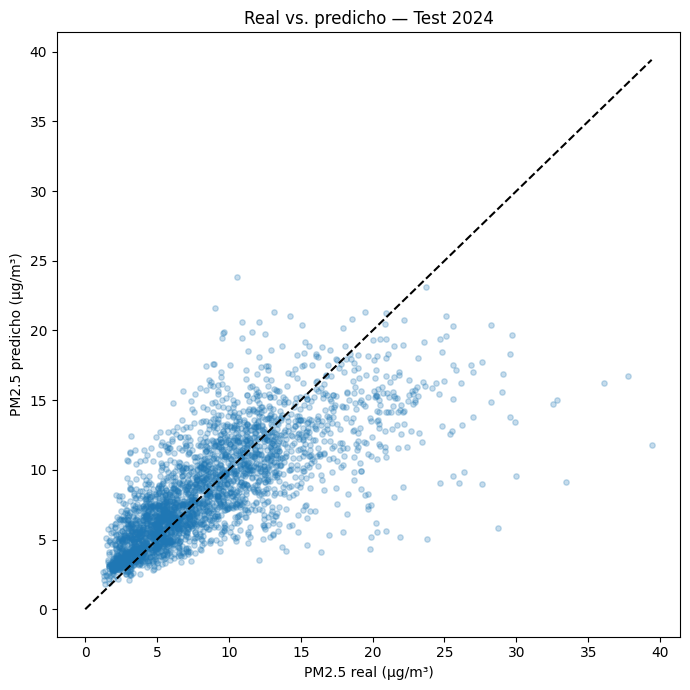

In [36]:
# ============================================================
# VALOR REAL VS PREDICCIÓN
# ============================================================

plt.figure(figsize=(7, 7))
plt.scatter(evaluacion["pm25"], evaluacion["prediccion"], alpha=0.25, s=15)
lim = [0, max(evaluacion["pm25"].max(), evaluacion["prediccion"].max())]
plt.plot(lim, lim, linestyle="--", color="black")
plt.xlabel("PM2.5 real (µg/m³)")
plt.ylabel("PM2.5 predicho (µg/m³)")
plt.title("Real vs. predicho — Test 2024")
plt.tight_layout()
plt.show()


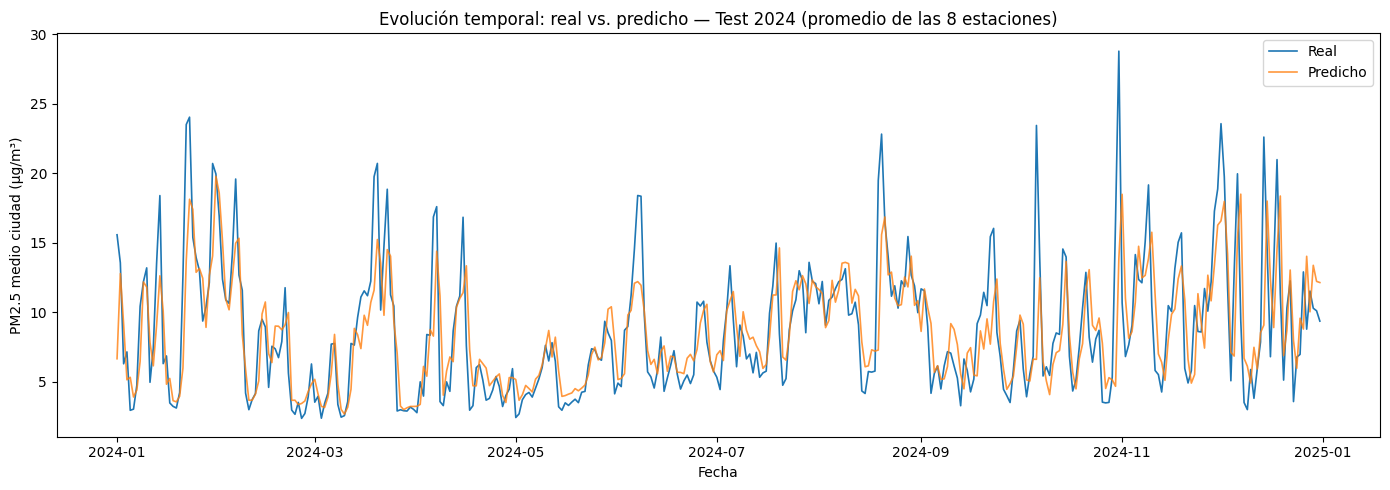

In [37]:
# ============================================================
# REAL VS. PREDICHO — EVOLUCIÓN TEMPORAL (TEST 2024)
# Promedio diario de las 8 estaciones, para que la serie sea legible.
# ============================================================

serie_temporal = (
    evaluacion
    .groupby("fecha")[["pm25", "prediccion"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(serie_temporal["fecha"], serie_temporal["pm25"], label="Real", linewidth=1.2)
plt.plot(serie_temporal["fecha"], serie_temporal["prediccion"], label="Predicho", linewidth=1.2, alpha=0.8)
plt.xlabel("Fecha")
plt.ylabel("PM2.5 medio ciudad (µg/m³)")
plt.title("Evolución temporal: real vs. predicho — Test 2024 (promedio de las 8 estaciones)")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Interpretabilidad con SHAP


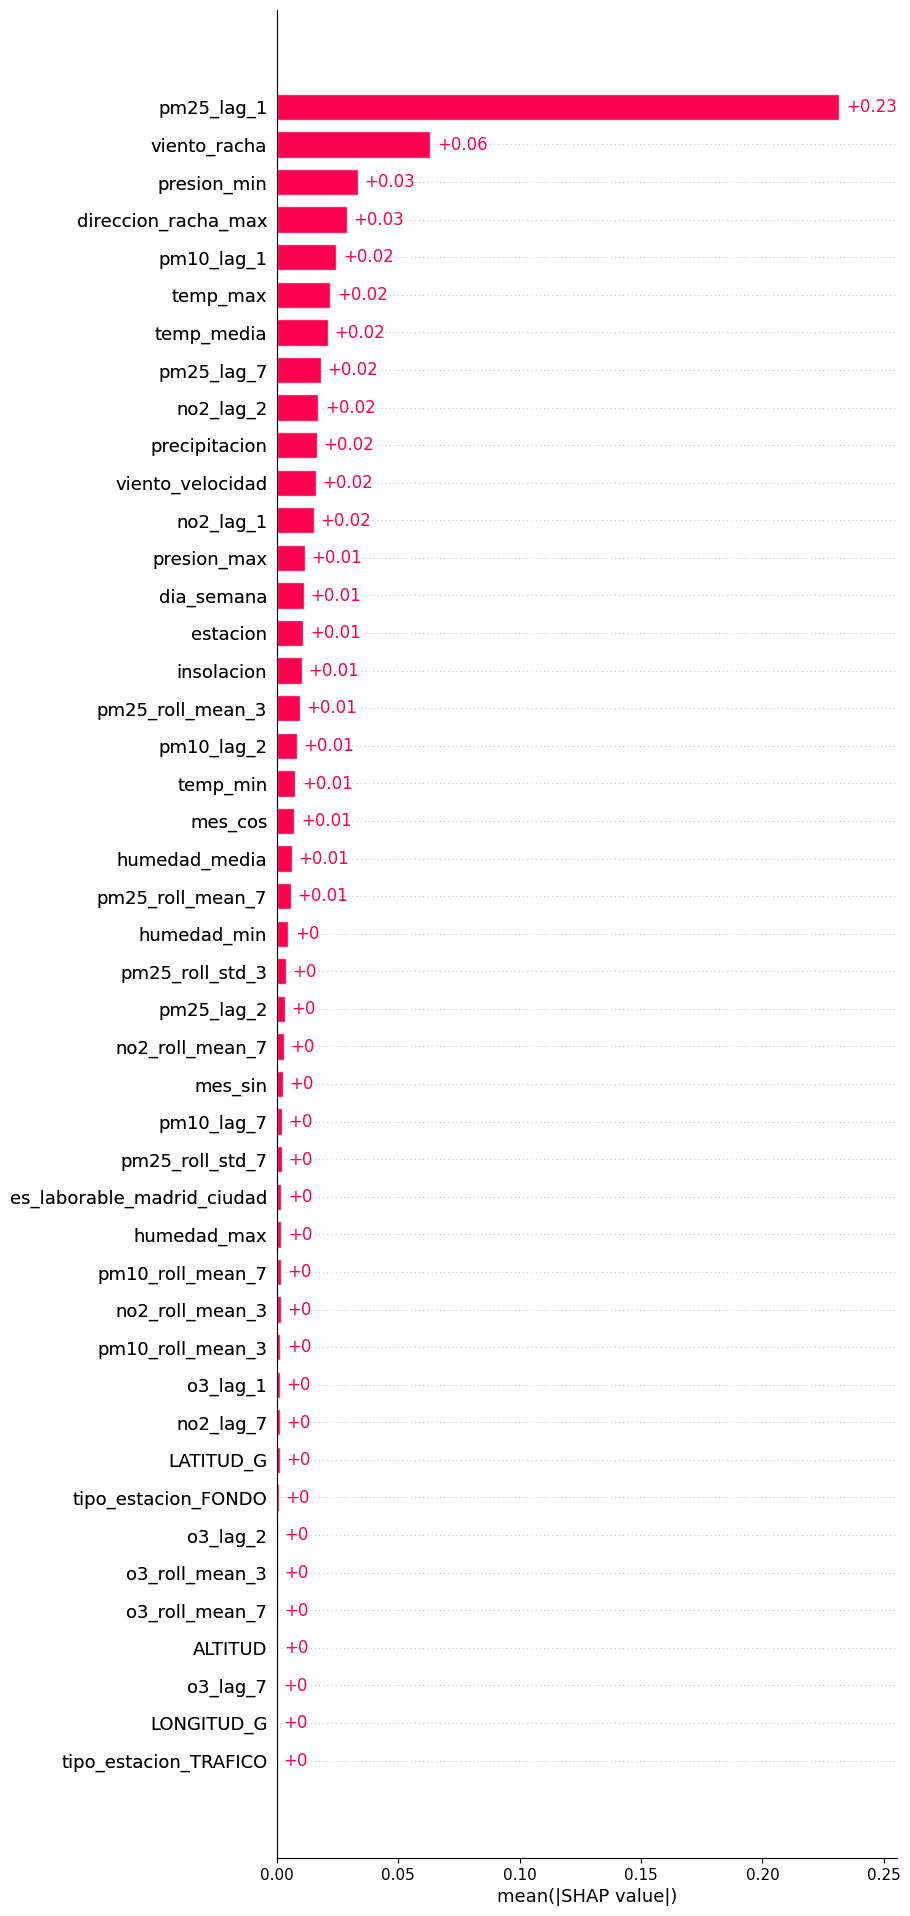

In [38]:
import shap

explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer(X_test)

shap.plots.bar(shap_values, max_display=len(FEATURES))


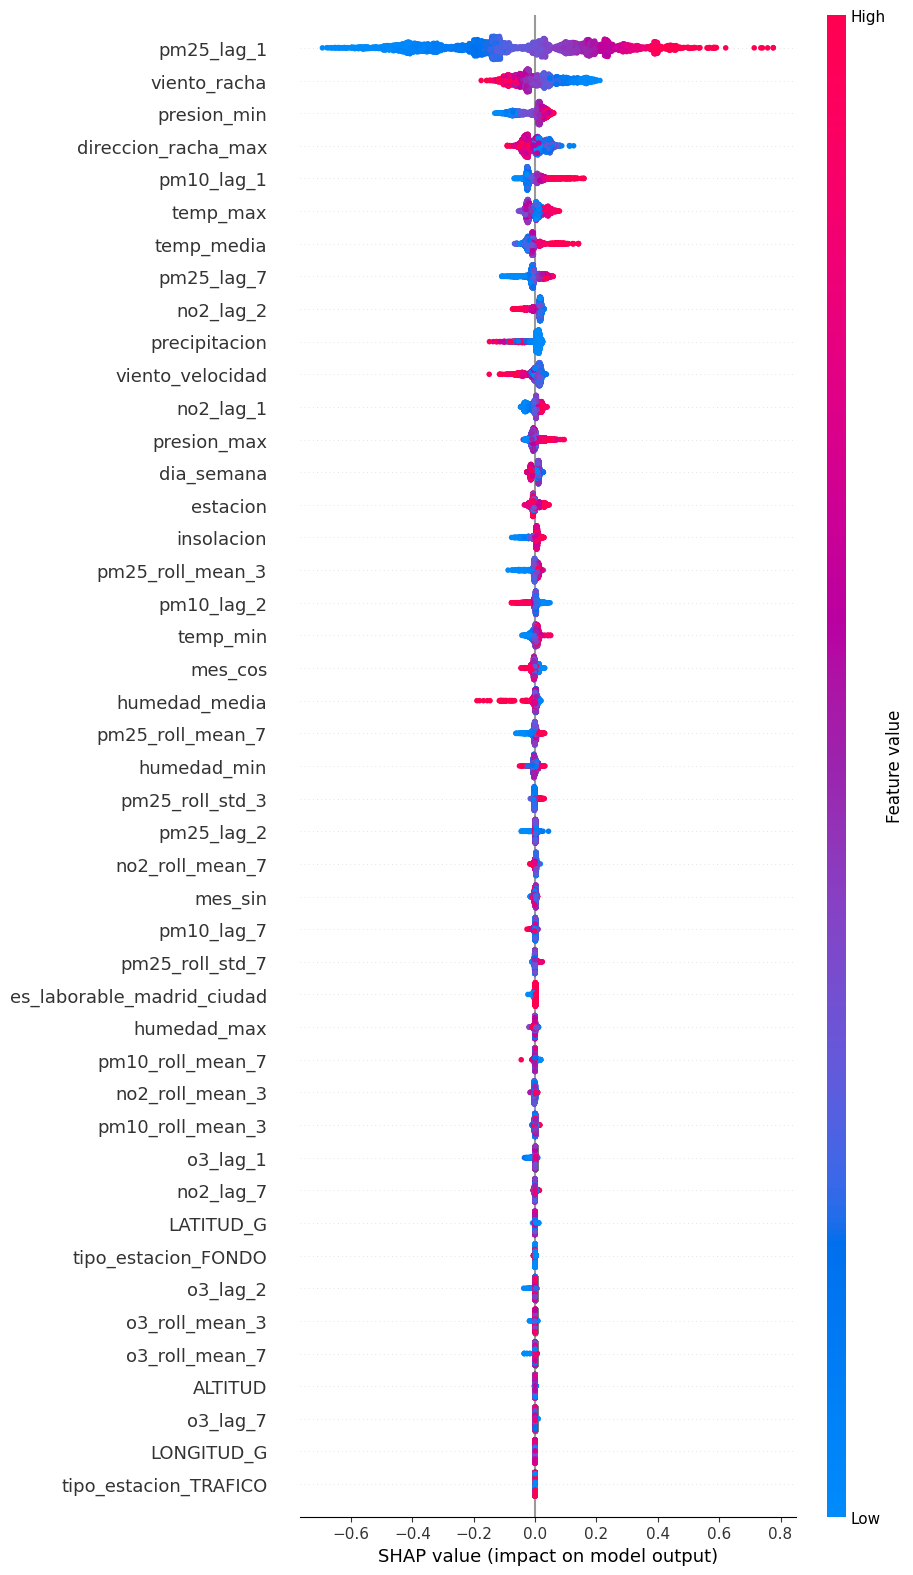

In [39]:
shap.plots.beeswarm(shap_values, max_display=len(FEATURES))


## 13. Guardado del modelo


In [40]:
# ============================================================
# GUARDAR MODELO, FEATURES Y NOTA SOBRE LA TRANSFORMACIÓN LOG
# ============================================================

import joblib

MODEL_PATH = ROOT / "models" / "xgboost_pm25_propio_final.joblib"
FEATURES_PATH = ROOT / "models" / "features_pm25_propio_final.joblib"

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(modelo_final, MODEL_PATH)
joblib.dump({
    "features": FEATURES,
    "target_transform": "log1p",
    "inverse_transform": "expm1",
}, FEATURES_PATH)

print("Modelo guardado:", MODEL_PATH)
print("Metadatos guardados:", FEATURES_PATH)
print("\nRECORDATORIO: las predicciones del modelo están en escala log1p.")
print("Aplicar np.expm1() al resultado de .predict() para obtener µg/m³.")


Modelo guardado: /home/claude/TFM/models/xgboost_pm25_propio_final.joblib
Metadatos guardados: /home/claude/TFM/models/features_pm25_propio_final.joblib

RECORDATORIO: las predicciones del modelo están en escala log1p.
Aplicar np.expm1() al resultado de .predict() para obtener µg/m³.


## 14. Conclusiones y limitaciones

**Resultado final (test 2024, escala original en µg/m³), con la configuración confirmada en reunión de equipo: datos de HOY (T) para predecir MAÑANA (T+1), desfase uniforme de 1 día para meteo y contaminantes:**

| Modelo | MAE | RMSE | R² | Sesgo |
|---|---|---|---|---|
| **XGBoost (propio)** | **2.45** | **3.59** | **0.55** | **+0.14** |
| Baseline: persistencia (ayer = hoy) | 2.94 | 4.34 | 0.33 | +0.001 |
| Baseline: media móvil 7 días | 3.76 | 5.16 | 0.06 | −0.12 |

El modelo mejora un **16.8%** el MAE frente al mejor baseline — una mejora clara respecto a la versión con desfase de 2 días (9.1%), y coherente con lo esperado: un dato de "hoy" es más informativo que uno de "hace dos días".

**Historial de esta decisión, documentado para trazabilidad:**
1. Primera versión: meteo del mismo día que el objetivo (fuga de información) → MAE 2.22 (cifra irreal).
2. Segunda versión: desfase de 2 días para meteo, contaminantes sin cambios → MAE 2.68.
3. Se probó aplicar también 2 días de desfase a los contaminantes → empeoró a MAE 3.25 (peor que el baseline).
4. **Versión actual, confirmada en reunión de equipo:** 1 día de desfase uniforme (datos de HOY para predecir MAÑANA) → **MAE 2.45**, la mejor cifra realista obtenida hasta ahora, sin fuga de información.

**Error por rango de concentración:**

| Rango PM2.5 | MAE |
|---|---|
| 0-5 | 1.69 |
| 5-10 | 1.86 |
| 10-15 | 2.49 |
| 15-25 | 5.27 |
| 25-50 | 13.92 |

**Limitación conocida:** el modelo sigue sin tener acceso a datos de intrusiones de polvo sahariano (calima) ni a pronósticos meteorológicos reales para el día objetivo (solo la observación de HOY). Los mayores errores de test 2024 se concentran en fechas puntuales (8-jun, 6-oct, 31-oct).

**Estado final: notebook alineado al estándar del equipo, con el desfase temporal (1 día, datos de HOY para predecir MAÑANA) confirmado en reunión y aplicado de forma uniforme a meteorología y contaminantes.**
